In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 40)

In [2]:
df_raw = pd.read_csv('opt.csv')
df_raw.shape

(823, 172)

In [3]:
df_raw.head()

,rownames,PID,Clinic,Group,Age,Black,White,Nat.Am,Asian,Hisp,Education,Public.Asstce,Hypertension,Diabetes,BL.Diab.Type,BMI,Use.Tob,BL.Cig.Day,Use.Alc,BL.Drks.Day,...,V5.PI,V5.CR,V5.FN,V5.S7,BL..AA,BL..PG,BL..TD,BL..TF,BL..PI,BL..CR,BL..FN,BL..S7,V5..AA,V5..PG,V5..TD,V5..TF,V5..PI,V5..CR,V5..FN,V5..S7
0,1,100034,NY,C,25,Yes,No,No,No,,8-12 yrs,No,N,No,NaN,NaN,Yes,5.0,No,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,100042,NY,C,21,Yes,No,No,No,,8-12 yrs,Yes,N,No,NaN,21.0,No,NaN,No,NaN,...,NaN,NaN,NaN,NaN,0.01,0.00,3.32,4.79,0.00,2.76,22.15,33.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,100067,NY,T,25,No,Yes,No,No,Yes,8-12 yrs,No,N,No,NaN,24.0,No,NaN,No,NaN,...,NaN,NaN,NaN,NaN,0.00,3.03,1.79,1.15,3.19,1.64,12.51,23.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,100083,NY,C,36,Yes,No,No,No,,MT 12 yrs,Yes,N,No,NaN,36.0,No,NaN,No,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,100091,NY,C,21,No,Yes,No,No,Yes,8-12 yrs,No,N,No,NaN,27.0,No,NaN,No,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
cols = ['PID', 'Clinic', 'Group', 'Age', 'BMI', 'N.qualifying.teeth',
        'BL.PD.avg', 'V3.PD.avg', 'V5.PD.avg', 'BL.CAL.avg', 'V5.CAL.avg',
        'GA.at.outcome', 'Birthweight', 'Birth.outcome']
df_raw[cols].describe()

,PID,Age,BMI,N.qualifying.teeth,BL.PD.avg,V3.PD.avg,V5.PD.avg,BL.CAL.avg,V5.CAL.avg,GA.at.outcome,Birthweight
count,823.000000,823.000000,750.000000,823.000000,823.000000,684.000000,659.000000,823.000000,659.000000,823.000000,809.000000
mean,252541.347509,25.978129,27.669333,14.761847,2.865181,2.676588,2.646127,1.412109,1.228715,268.476306,3198.813350
std,106737.056578,5.565973,7.127299,6.747021,0.562013,0.499102,0.499192,0.688277,0.716115,28.252453,683.301508
min,100034.000000,16.000000,15.000000,3.000000,1.851000,1.601000,1.536000,0.185000,0.018000,103.000000,101.000000
25%,200501.000000,22.000000,23.000000,9.000000,2.495500,2.339000,2.301000,0.862000,0.622500,267.000000,2960.000000
50%,202717.000000,25.000000,26.000000,14.000000,2.732000,2.585000,2.565000,1.370000,1.263000,275.000000,3265.000000
75%,302208.000000,30.000000,31.000000,20.000000,3.097500,2.895500,2.877500,1.885000,1.760500,281.000000,3580.000000
max,402477.000000,44.000000,68.000000,28.000000,6.967000,5.464000,5.429000,5.119000,4.350000,302.000000,5160.000000


In [5]:
df_raw['Birth.outcome'].value_counts()

Birth.outcome
Live birth              793
Non-live birth           19
Lost to FU                9
Elective abortion         2
Name: count, dtype: int64

In [6]:
text_cols = df_raw.columns[df_raw.dtypes.astype(str).isin(['object', 'str'])]
dot_cols = [c for c in text_cols if df_raw[c].astype('str').str.strip().eq('.').any()]

df_raw['OAA5'].unique()[:5]

<StringArray>
['8.264', '.', '2.534', '4.299', '2.122']
Length: 5, dtype: str

In [7]:
df = df_raw.copy()
df[text_cols] = df[text_cols].apply(lambda s: s.astype('str').str.strip())
df[text_cols] = df[text_cols].replace(to_replace=['', '.'], value=[np.nan, np.nan])
df[dot_cols] = df[dot_cols].apply(pd.to_numeric, errors='coerce')

df['OAA5'].unique()[:5]

array([8.264,   nan, 2.534, 4.299, 2.122])

In [8]:
print('missing before replace:', df_raw.isnull().sum().sum())
print('missing after  replace:', df.isnull().sum().sum())
df['Birth.outcome'].value_counts()

missing before replace: 28285
missing after  replace: 34320


Birth.outcome
Live birth           793
Non-live birth        19
Lost to FU             9
Elective abortion      2
Name: count, dtype: int64

In [9]:
df['Group'] = df['Group'].replace({'C': 'Control', 'T': 'Treatment'})
df['Group'].value_counts()

Group
Treatment    413
Control      410
Name: count, dtype: int64

In [10]:
print('duplicated rows:', df.duplicated().sum())
print('duplicated PIDs:', df.duplicated(['PID']).sum())
df.duplicated().head()

duplicated rows: 0
duplicated PIDs: 0


0    False
1    False
2    False
3    False
4    False
dtype: bool

In [11]:
profile = ['Clinic', 'Group', 'Age']
print('rows with a repeated profile:', df.duplicated(profile).sum())
print('after drop_duplicates      :', len(df.drop_duplicates(profile)))

rows with a repeated profile: 639
after drop_duplicates      : 184


In [12]:
df.isnull().sum().sort_values(ascending=False).head(10)

BL.Drks.Day     810
BL.Diab.Type    799
BL.Cig.Day      731
Induced.ab      557
Spont.ab        539
Strep.B         522
V5.TD           498
V5.PG           498
V5.PI           498
V5.CR           498
dtype: int64

In [13]:
total = df.isnull().sum().sum()
print('total missing values:', total)
print('percent of dataframe:', round(100 * total / df.size, 2))

total missing values: 34320
percent of dataframe: 24.24


In [14]:
df[cols].count()

PID                   823
Clinic                823
Group                 823
Age                   823
BMI                   750
N.qualifying.teeth    823
BL.PD.avg             823
V3.PD.avg             684
V5.PD.avg             659
BL.CAL.avg            823
V5.CAL.avg            659
GA.at.outcome         823
Birthweight           809
Birth.outcome         823
dtype: int64

In [15]:
print('rows if we drop any NaN :', len(df.dropna()))
print("rows after how='all'    :", len(df.dropna(how='all')))
print("cols after how='all'    :", df.dropna(how='all', axis=1).shape[1])

rows if we drop any NaN : 0
rows after how='all'    : 823
cols after how='all'    : 172


In [16]:
for t in [823, 700, 500, 300]:
    print(f'thresh={t} -> {df.dropna(thresh=t, axis=1).shape[1]} columns kept')

thresh=823 -> 37 columns kept
thresh=700 -> 71 columns kept
thresh=500 -> 121 columns kept
thresh=300 -> 167 columns kept


In [17]:
analysis = df.dropna(subset=['Birthweight', 'GA.at.outcome', 'BL.PD.avg'])
print('analysis set:', len(analysis), 'of', len(df))

analysis set: 809 of 823


In [18]:
print('numpy  mean:', df['BMI'].to_numpy(dtype='float64').mean())
print('pandas mean:', df['BMI'].mean())

numpy  mean: nan
pandas mean: 27.669333333333334


In [19]:
cig = df['BL.Cig.Day']
print('reported values:', cig.count(), 'of', len(cig))
print('sum :', cig.sum())
print('mean:', cig.mean())

reported values: 92 of 823
sum : 802.0
mean: 8.717391304347826


In [20]:
check = ['BMI', 'Birthweight', 'V5.PD.avg']
pd.DataFrame({'mean (NaN skipped)': df[check].mean(),
              'mean after fillna(0)': df[check].fillna(0).mean()}).round(2)

,mean (NaN skipped),mean after fillna(0)
BMI,27.67,25.22
Birthweight,3198.81,3144.40
V5.PD.avg,2.65,2.12


In [21]:
df['BL.Cig.Day'] = df['BL.Cig.Day'].fillna(0)
df['BL.Drks.Day'] = df['BL.Drks.Day'].fillna(0)
df['BMI'] = df['BMI'].fillna(df['BMI'].median())

df[['BL.Cig.Day', 'BL.Drks.Day', 'BMI']].isnull().sum()

BL.Cig.Day     0
BL.Drks.Day    0
BMI            0
dtype: int64

In [22]:
s = df['V5.PD.avg'].head(10)
pd.DataFrame({'original': s, 'ffill': s.ffill(), 'bfill': s.bfill()})

,original,ffill,bfill
0,2.929,2.929,2.929
1,NaN,2.929,3.660
2,NaN,2.929,3.660
3,3.660,3.660,3.660
4,2.786,2.786,2.786
5,NaN,2.786,2.810
6,2.810,2.810,2.810
7,NaN,2.810,2.846
8,2.846,2.846,2.846
9,NaN,2.846,NaN


In [23]:
measures = ['GE', 'PD.avg', 'CAL.avg', 'Calc.I', 'Pl.I']
visits = ['BL', 'V3', 'V5']

visit_matrix = pd.DataFrame({v: [df[f'{v}.{m}'].mean() for m in measures] for v in visits},
                            index=measures).round(3)
visit_matrix

,BL,V3,V5
GE,1.434,1.296,1.284
PD.avg,2.865,2.677,2.646
CAL.avg,1.412,1.229,1.229
Calc.I,1.142,0.713,0.711
Pl.I,1.236,0.977,0.978


In [24]:
stacked = visit_matrix.stack()
stacked

GE       BL    1.434
         V3    1.296
         V5    1.284
PD.avg   BL    2.865
         V3    2.677
         V5    2.646
CAL.avg  BL    1.412
         V3    1.229
         V5    1.229
Calc.I   BL    1.142
         V3    0.713
         V5    0.711
Pl.I     BL    1.236
         V3    0.977
         V5    0.978
dtype: float64

In [25]:
stacked.unstack()

,BL,V3,V5
GE,1.434,1.296,1.284
PD.avg,2.865,2.677,2.646
CAL.avg,1.412,1.229,1.229
Calc.I,1.142,0.713,0.711
Pl.I,1.236,0.977,0.978


In [26]:
df.groupby(['Clinic', 'Group'])['BL.PD.avg'].mean().round(3).unstack()

Group,Control,Treatment
Clinic,,
KY,2.827,2.877
MN,3.170,3.177
MS,2.635,2.656
NY,2.590,2.778


In [27]:
df['Age.Group'] = pd.cut(df['Age'], bins=[15, 19, 24, 29, 34, 45],
                         labels=['<=19', '20-24', '25-29', '30-34', '35+'])
df['Age.Group'].value_counts().sort_index()

Age.Group
<=19      81
20-24    304
25-29    228
30-34    133
35+       77
Name: count, dtype: int64

In [28]:
df['BMI.Category'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 100],
                            labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
df['BMI.Category'].value_counts().sort_index()

BMI.Category
Underweight     27
Normal         306
Overweight     294
Obese          196
Name: count, dtype: int64

In [29]:
df['PD.Quartile'] = pd.qcut(df['BL.PD.avg'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
print(pd.qcut(df['BL.PD.avg'], 4).value_counts().sort_index())
df.groupby('PD.Quartile', observed=True)[['GA.at.outcome', 'Birthweight']].mean().round(1)

BL.PD.avg
(1.85, 2.496]     206
(2.496, 2.732]    210
(2.732, 3.098]    201
(3.098, 6.967]    206
Name: count, dtype: int64


,GA.at.outcome,Birthweight
PD.Quartile,,
Q1,265.8,3170.2
Q2,266.7,3135.3
Q3,271.2,3260.3
Q4,270.3,3232.3


In [30]:
df['PD.Change'] = df['V5.PD.avg'] - df['BL.PD.avg']
df['PD.Change'].describe()

count    659.000000
mean      -0.214924
std        0.446991
min       -2.350000
25%       -0.425000
50%       -0.173000
75%        0.054500
max        1.043000
Name: PD.Change, dtype: float64

In [31]:
PDChange = df['PD.Change']
df.loc[np.abs(PDChange) > 1.0, ['PID', 'Clinic', 'Group', 'BL.PD.avg', 'V5.PD.avg', 'PD.Change']]

,PID,Clinic,Group,BL.PD.avg,V5.PD.avg,PD.Change
176,200091,MN,Treatment,3.705,2.686,-1.019
224,200737,MN,Treatment,2.972,1.951,-1.021
234,200844,MN,Treatment,3.201,2.021,-1.180
248,200992,MN,Treatment,4.315,2.863,-1.452
252,201032,MN,Treatment,4.302,3.179,-1.123
256,201073,MN,Treatment,4.250,3.000,-1.250
258,201099,MN,Treatment,3.931,2.521,-1.410
260,201115,MN,Treatment,3.872,2.571,-1.301
265,201164,MN,Treatment,4.370,2.352,-2.018
269,201214,MN,Treatment,3.587,2.500,-1.087


In [32]:
def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)

report = []
for c in ['Age', 'BMI', 'BL.PD.avg', 'GA.at.outcome', 'Birthweight', 'PD.Change']:
    s = df[c].dropna()
    lo, hi = iqr_bounds(s)
    report.append({'column': c, 'lower': round(lo, 2), 'upper': round(hi, 2),
                   'outliers': int(((s < lo) | (s > hi)).sum())})

pd.DataFrame(report).set_index('column')

,lower,upper,outliers
column,,,
Age,10.00,42.00,2
BMI,12.50,40.50,40
BL.PD.avg,1.59,4.00,33
GA.at.outcome,246.00,302.00,60
Birthweight,2030.00,4510.00,44
PD.Change,-1.14,0.77,31


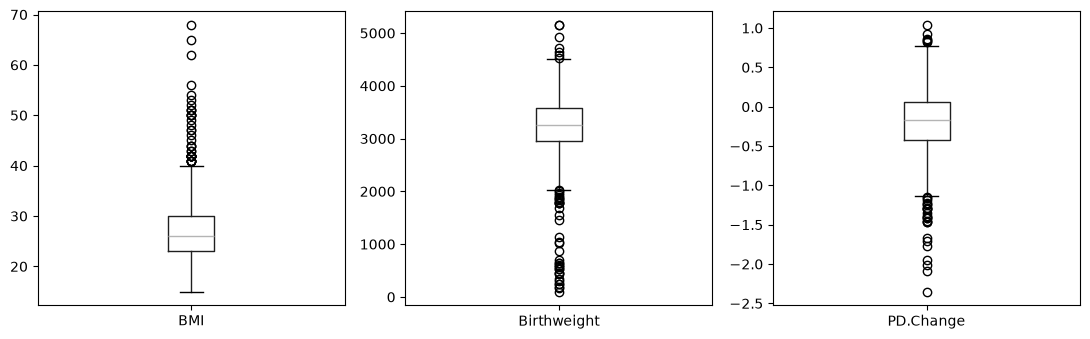

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, c in zip(axes, ['BMI', 'Birthweight', 'PD.Change']):
    df.boxplot(column=c, ax=ax, grid=False)
plt.tight_layout()
plt.show()

In [34]:
lo, hi = iqr_bounds(df['PD.Change'].dropna())
bad = df['PD.Change'].notnull() & ((df['PD.Change'] < lo) | (df['PD.Change'] > hi))

df_clean = df[~bad]
print(f'bounds: [{lo:.2f}, {hi:.2f}]')
print('rows removed:', bad.sum(), '| rows kept:', len(df_clean))

bounds: [-1.14, 0.77]
rows removed: 31 | rows kept: 792


In [35]:
df_clean[['PID', 'Clinic', 'Group', 'Age', 'Age.Group', 'BMI', 'BMI.Category',
          'BL.PD.avg', 'V5.PD.avg', 'PD.Change', 'PD.Quartile', 'Birthweight']].head()

,PID,Clinic,Group,Age,Age.Group,BMI,BMI.Category,BL.PD.avg,V5.PD.avg,PD.Change,PD.Quartile,Birthweight
0,100034,NY,Control,25,25-29,26.0,Overweight,2.696,2.929,0.233,Q2,3490.0
1,100042,NY,Control,21,20-24,21.0,Normal,2.685,NaN,NaN,Q2,2350.0
2,100067,NY,Treatment,25,25-29,24.0,Normal,2.821,NaN,NaN,Q3,2525.0
4,100091,NY,Control,21,20-24,27.0,Overweight,2.768,2.786,0.018,Q3,3865.0
5,100109,NY,Treatment,40,35+,24.0,Normal,2.932,NaN,NaN,Q3,3120.0


In [36]:
df_clean.to_csv('opt_transformed.csv', index=False)
print('saved opt_transformed.csv', df_clean.shape)

saved opt_transformed.csv (792, 176)


In [37]:
num = ['Age', 'BMI', 'N.qualifying.teeth', 'BL.GE', 'BL..BOP', 'BL.PD.avg',
       'BL.CAL.avg', 'BL.Calc.I', 'BL.Pl.I', 'V5.PD.avg',
       'GA.at.outcome', 'Birthweight', 'Apgar1', 'Apgar5']
df_clean[num].dtypes

Age                     int64
BMI                   float64
N.qualifying.teeth      int64
BL.GE                 float64
BL..BOP               float64
BL.PD.avg             float64
BL.CAL.avg            float64
BL.Calc.I             float64
BL.Pl.I               float64
V5.PD.avg             float64
GA.at.outcome           int64
Birthweight           float64
Apgar1                float64
Apgar5                float64
dtype: object

In [38]:
mean = df_clean['Birthweight'].mean()
median = df_clean['Birthweight'].median()
mode = df_clean['Birthweight'].mode()[0]
print('mean   =', round(mean, 2))
print('median =', median)
print('mode   =', mode)

mean   = 3197.02
median = 3268.0
mode   = 3190.0


In [39]:
s = df_clean['Birthweight']
print('std      =', round(s.std(), 2))
print('variance =', round(s.var(), 2))
print('min, max =', s.min(), s.max())
print('range    =', s.max() - s.min())
print('Q1, Q3   =', s.quantile(0.25), s.quantile(0.75))
print('IQR      =', s.quantile(0.75) - s.quantile(0.25))

std      = 689.48
variance = 475388.22
min, max = 101.0 5160.0
range    = 5059.0
Q1, Q3   = 2966.25 3578.75
IQR      = 612.5


In [40]:
df_clean[num].agg(['mean', 'median', 'std', 'var', 'min', 'max']).round(2).T

,mean,median,std,var,min,max
Age,25.94,25.00,5.57,31.08,16.00,44.00
BMI,27.46,26.00,6.83,46.63,15.00,68.00
N.qualifying.teeth,14.47,13.00,6.57,43.14,3.00,28.00
BL.GE,1.42,1.40,0.41,0.17,0.43,3.00
BL..BOP,68.73,68.10,17.08,291.72,33.95,100.00
BL.PD.avg,2.83,2.71,0.51,0.26,1.85,6.08
BL.CAL.avg,1.38,1.33,0.66,0.44,0.18,5.12
BL.Calc.I,1.11,1.03,0.60,0.36,0.00,2.69
BL.Pl.I,1.22,1.22,0.48,0.23,0.06,2.78
V5.PD.avg,2.64,2.56,0.49,0.24,1.54,5.43
